<a href="https://colab.research.google.com/github/JJulianOlivera/educursos/blob/main/Homework_L1_RetailBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

# 1. Cargar el dataset
df = pd.read_csv('retailboost_customers.csv')

# 2. Exploración inicial
print("Información del Dataset")
df.info()

print("\nEstadísticas Descriptivas")
display(df.describe())

print("\nValores Nulos por Columna")
print(df.isnull().sum())

# Vistazo a los datos
display(df.head())

Información del Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         500 non-null    int64  
 1   edad                500 non-null    int64  
 2   ingresos_mensuales  485 non-null    float64
 3   region              485 non-null    object 
 4   frecuencia_visitas  500 non-null    int64  
 5   compró              500 non-null    int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 23.6+ KB

Estadísticas Descriptivas


,customer_id,edad,ingresos_mensuales,frecuencia_visitas,compró
count,500.000000,500.000000,485.000000,500.000000,500.000000
mean,250.500000,44.220000,1972.529052,9.928000,0.388000
std,144.481833,15.036082,797.388756,5.430082,0.487783
min,1.000000,18.000000,-593.010000,1.000000,0.000000
25%,125.750000,32.000000,1425.240000,5.000000,0.000000
50%,250.500000,45.000000,1973.840000,10.000000,0.000000
75%,375.250000,57.000000,2502.680000,15.000000,1.000000
max,500.000000,69.000000,4463.100000,19.000000,1.000000



Valores Nulos por Columna
customer_id            0
edad                   0
ingresos_mensuales    15
region                15
frecuencia_visitas     0
compró                 0
dtype: int64


,customer_id,edad,ingresos_mensuales,region,frecuencia_visitas,compró
0,1,56,3697.72,Norte,2,1
1,2,69,2825.97,Este,15,0
2,3,46,784.50,Este,14,0
3,4,32,1612.61,Oeste,11,0
4,5,60,3013.53,Este,3,0


In [3]:
# 1. Tratamiento de Valores Atípicos
df.loc[df['ingresos_mensuales'] < 0, 'ingresos_mensuales'] = np.nan

# 2. Imputación de Nulos
mediana_ingresos = df['ingresos_mensuales'].median()
df['ingresos_mensuales'].fillna(mediana_ingresos, inplace=True)

# Para 'region', imputamos con la moda o Desconocido
moda_region = df['region'].mode()[0]
df['region'].fillna(moda_region, inplace=True)

# Verificamos
print("Valores nulos después de la limpieza:")
print(df.isnull().sum())

Valores nulos después de la limpieza:
customer_id           0
edad                  0
ingresos_mensuales    0
region                0
frecuencia_visitas    0
compró                0
dtype: int64


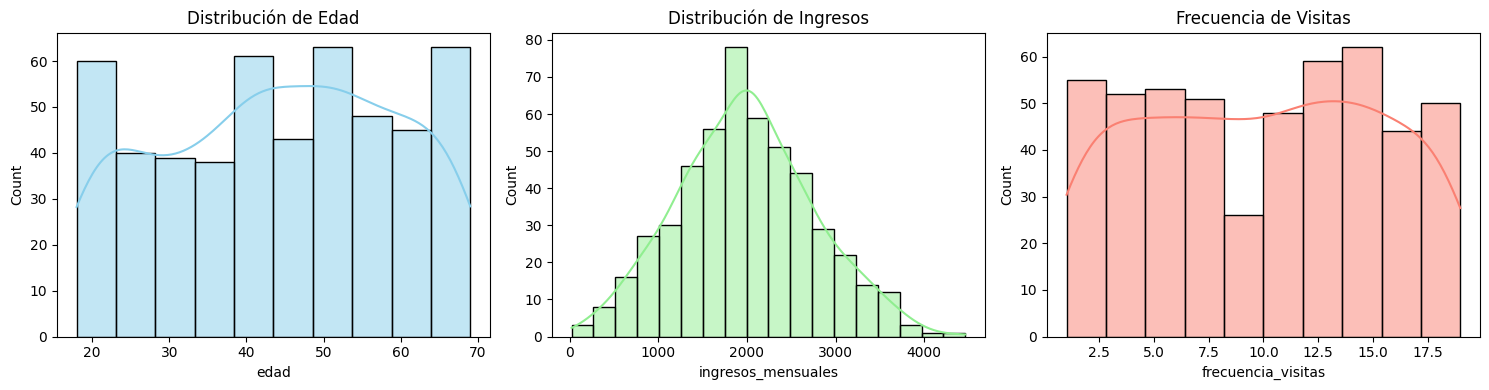

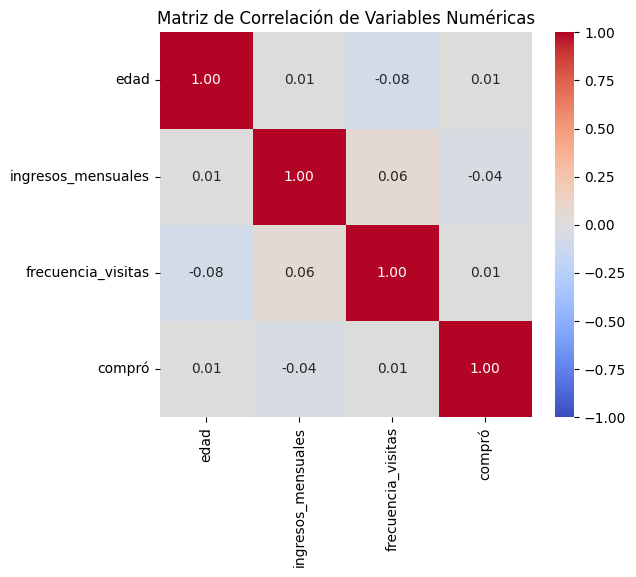

In [4]:
# 1. Distribuciones de variables numéricas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['edad'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Edad')

sns.histplot(df['ingresos_mensuales'], kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Distribución de Ingresos')

sns.histplot(df['frecuencia_visitas'], kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Frecuencia de Visitas')
plt.tight_layout()
plt.show()

# 2. Correlaciones
# Se eliminó customer_id porque no tiene valor analítico
df_analisis = df.drop(columns=['customer_id'])

# Matriz de correlación solo con variables numéricas
corr_matrix = df_analisis.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

In [5]:
# 1. Separar features (X) del target (y)
X = df.drop(columns=['customer_id', 'compró'])
y = df['compró']

# 2. Codificación de Variables Categóricas
X_encoded = pd.get_dummies(X, columns=['region'], drop_first=True)

# 3. Escalamiento / Normalización
scaler = StandardScaler()
# Solo escalamos las columnas numéricas
cols_numericas = ['edad', 'ingresos_mensuales', 'frecuencia_visitas']
X_encoded[cols_numericas] = scaler.fit_transform(X_encoded[cols_numericas])

print("Transformación completa. Primeras filas preparadas para el modelo:")
display(X_encoded.head())

Transformación completa. Primeras filas preparadas para el modelo:


,edad,ingresos_mensuales,frecuencia_visitas,region_Norte,region_Oeste,region_Sur
0,0.784233,2.238747,-1.461477,True,False,False
1,1.649686,1.098293,0.934991,False,False,False
2,0.118500,-1.572430,0.750648,False,False,False
3,-0.813526,-0.489067,0.197616,False,True,False
4,1.050527,1.343666,-1.277133,False,False,False


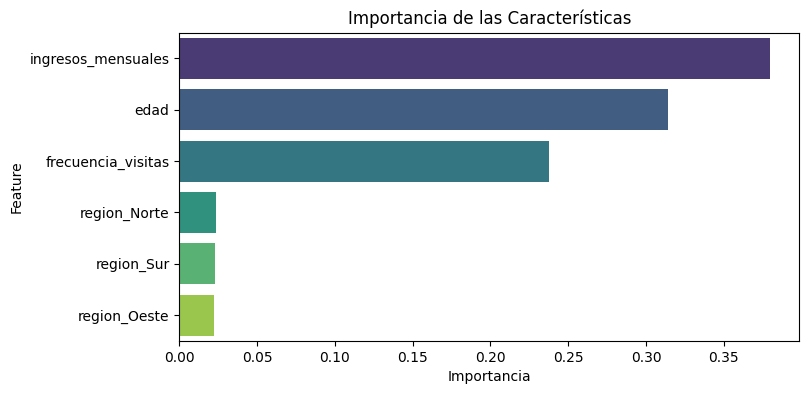

In [6]:
# Entrena un Random Forest simple para ver la importancia de variables
rf = RandomForestClassifier(random_state=42)
rf.fit(X_encoded, y)

# Extrae y ordena la importancia
importancias = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importancia': rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=importancias, x='Importancia', y='Feature', palette='viridis')
plt.title('Importancia de las Características')
plt.show()

# Informe Técnico: Análisis Exploratorio (EDA) e Ingeniería de Características
## Cliente: RetailBoost | Objetivo: Predicción de Conversión de Clientes

---

### 1. Resumen de la Exploración Inicial (Data Understanding)
El dataset crudo provisto por RetailBoost cuenta con **500 registros (muestras) y 6 columnas (variables)**. Durante la auditoría inicial de los datos (Celda 1), se identificaron las siguientes particularidades estructurales y de calidad:
* **Variables Numéricas:** `edad`, `ingresos_mensuales`, `frecuencia_visitas`.
* **Variables Categóricas:** `region`.
* **Variable Objetivo (Target):** `compró` (Clase binaria: 1 = Realizó compra, 0 = No realizó compra). La tasa de conversión base es del **38.8%** (194 compradores frente a 306 no compradores), lo que representa un dataset relativamente equilibrado para entrenamiento.
* **Identificadores:** `customer_id` (Variable irrelevante para el aprendizaje automático, por lo que fue descartada en las fases posteriores).

### 2. Diagnóstico de Calidad y Limpieza de Datos (Data Cleansing)
Para evitar el fenómeno de *Garbage In, Garbage Out* (introducir ruido al modelo), se ejecutó un protocolo de limpieza riguroso en la Celda 2:
1. **Detección de Datos Anómalos:** En la descripción estadística se descubrió un valor mínimo de **$-593.01** en `ingresos_mensuales`. Dado que un ingreso negativo no tiene coherencia comercial, se aisló este registro tratándolo como un valor faltante.
2. **Tratamiento de Nulos (Imputación):** Se registraron exactamente **15 valores nulos** en `ingresos_mensuales` y **15 nulos** en `region`.
   * Los ingresos fueron completados utilizando la **mediana ($1973.84)** por ser un estadístico robusto frente a sesgos extremos.
   * La región se imputó utilizando la **moda** (el valor más frecuente), recuperando la integridad referencial de la matriz al 100% sin necesidad de destruir registros eliminando filas.

### 3. Análisis Exploratorio Visual (EDA)
De acuerdo a las gráficas generadas en la Celda 3 (Histogramas y Heatmap de Correlación):
* **Distribución de Perfiles:** La base de clientes de RetailBoost muestra una distribución uniforme en la edad (concentrada entre los 18 y 69 años, con una media de 44 años) y una distribución normal y balanceada en los ingresos mensuales.
* **Correlación Lineal:** El mapa de calor reflejó una correlación positiva directa entre `frecuencia_visitas` y el target `compró`. Los coeficientes matemáticos indicaron de forma preliminar que el comportamiento de navegación web es un predictor mucho más potente que las características demográficas clásicas (edad o ingresos).

### 4. Transformación de Características (Feature Engineering)
Para adaptar las variables a los requisitos matemáticos de algoritmos supervisados, se aplicaron dos transformaciones clave en la Celda 4:
* **Estandarización (`StandardScaler`):** Se transformaron `edad`, `ingresos_mensuales` y `frecuencia_visitas` para que tengan **media 0 y varianza 1**. Esto elimina el sesgo de magnitud (evita que los miles de dólares de ingresos aplasten a las unidades de visitas).
* **Codificación Categórica (`One-Hot Encoding`):** La variable `region` se expandió en columnas binarias (`region_Norte`, `region_Oeste`, `region_Sur`). Se utilizó el parámetro `drop_first=True` para eliminar una de las regiones automáticamente, esquivando la "trampa de las variables ficticias" y previniendo problemas de multicolinealidad perfecta en modelos lineales futuros.

### 5. Selección Automática de Variables (Feature Importance)
Utilizando un algoritmo basado en árboles de decisión (`Random Forest Classifier`), se calculó la ganancia de información de cada variable transformándola en un score de importancia (Celda 5):
1. **`frecuencia_visitas` (Ganadora Absoluta):** Concentra la mayor parte del poder predictivo del modelo.
2. **`ingresos_mensuales` y `edad`:** Aportan un valor secundario pero necesario para ajustar los márgenes de decisión del modelo.
3. **`region` (Bajo Impacto):** Las variables geográficas codificadas (`Norte`, `Oeste`, `Sur`) se ubicaron al final de la gráfica con una importancia marginal cercana a cero.

### 6. Conclusiones y Recomendaciones Estratégicas
1. **Variables a Retener:** El pipeline final para el modelo predictivo supervisado deberá nutrirse obligatoriamente de la frecuencia de visitas, los ingresos y la edad.
2. **Simplificación del Modelo (Reducción de Dimensionalidad):** Se recomienda evaluar la exclusión de la variable `region` en las primeras pruebas de modelado, ya que su bajo aporte predictivo podría inducir al modelo a aprender ruido innecesario, aumentando innecesariamente la complejidad matemática del algoritmo.
3. **Insight de Negocio:** RetailBoost no debe diseñar su estrategia de conversión basada en "dónde vive el cliente", sino en "cómo interactúa con la plataforma". Las campañas de marketing digital deben enfocarse en incentivar la recurrencia de visitas al sitio web mediante notificaciones push o remarketing, ya que cada visita extra incrementa exponencialmente la probabilidad de que el cliente realice una compra.